# Marketing Analytics Report  
### Data-Driven Evaluation of Campaign Performance  

**Author: Huang Xinyi**  
**Date: 26/02/2026**  

---

## Objective

The objective of this analysis is to investigate why recent marketing campaigns underperformed and to provide data-driven recommendations to improve performance.


# 1. Data Loading & Overview

This section loads the dataset and provides an initial overview of its structure.


## 1.1 Load Dataset
We begin by importing the required libraries and loading the dataset.


In [2]:
#使用pandas库，读取数据，数据存在当前目录下
import pandas as pd 
data = pd. read_csv('1-Marketing Analytics.csv')

## 1.2 Data Structure
We examine the shape, column types, and first few rows of the dataset.


In [3]:
#查看数据的基本情况
data. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [4]:
#用 duplicated().sum()方法，查看是否存在重复值。可以看到没有重复值
duplicate_checking = data.duplicated().sum()

In [5]:
#打印了看看
duplicate_checking

np.int64(0)

In [6]:
print(int(duplicate_checking))

0


### 1.3 Missing Values
We check for missing values and decide how to handle them.


In [7]:
#通过 data.isnull().sum()方法，查看是否存在数据缺失情况。
missing_values = data. isnull(). sum()
missing_values

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

## 1.4 Outlier Detection
We inspect numerical variables for potential outliers using boxplots and summary statistics.


需要 transformation的变量：
1.所有 Mnt 开头的变量
2.强烈右偏（Right Skewed）2.购买次数类（NumDealsPurchases、NumWebPurchases、NumCatalogPurchases、NumStorePurchases、NumWebVisitsMonth这些也是明显右偏。）
强烈右偏会让：少数极端用户决定走向。log transformation 的本质是：让“极端值冷静下来”。

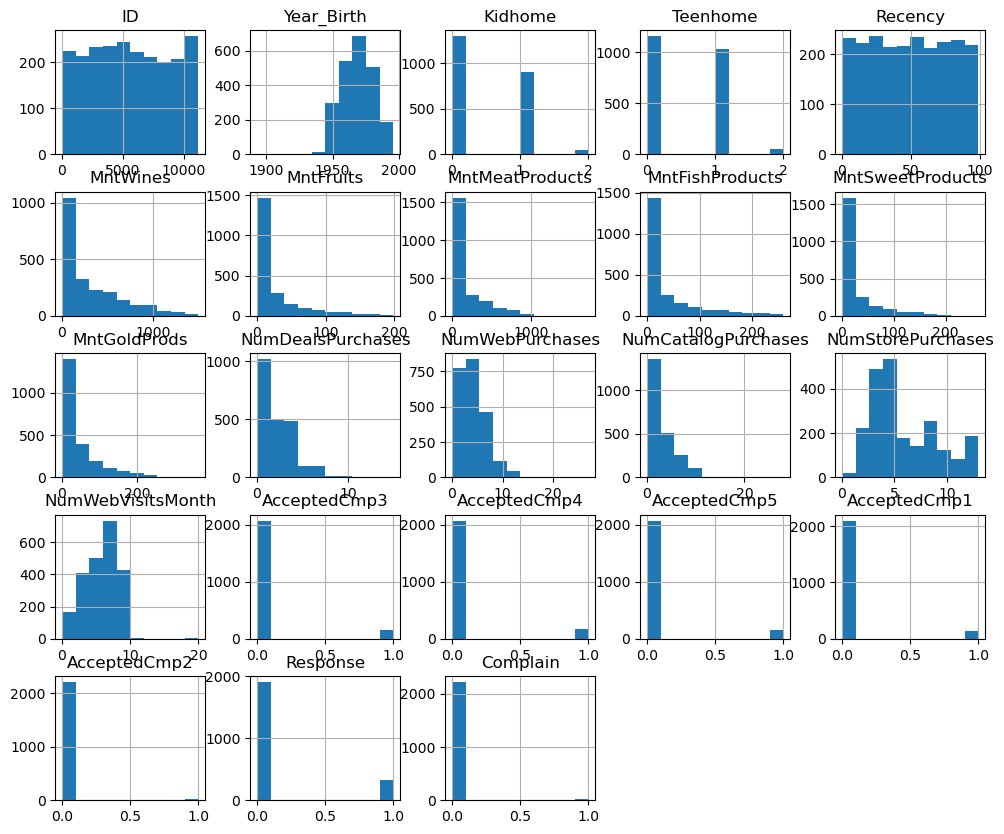

In [8]:
#看每个数值变量的“分布形状”
import matplotlib.pyplot as plt

data.hist(figsize=(12,10))
plt.show()

skew值	
0	完全对称
0 ~ 0.5	基本正常
0.5 ~ 1	轻度右偏
skew> 1	明显右偏
skew> 2	强烈右偏

In [11]:
data.skew(numeric_only=True)

ID                      0.039832
Year_Birth             -0.349944
Kidhome                 0.635288
Teenhome                0.407115
Recency                -0.001987
MntWines                1.175771
MntFruits               2.102063
MntMeatProducts         2.083233
MntFishProducts         1.919769
MntSweetProducts        2.136081
MntGoldProds            1.886106
NumDealsPurchases       2.418569
NumWebPurchases         1.382794
NumCatalogPurchases     1.880989
NumStorePurchases       0.702237
NumWebVisitsMonth       0.207926
AcceptedCmp3            3.291705
AcceptedCmp4            3.241574
AcceptedCmp5            3.291705
AcceptedCmp1            3.555444
AcceptedCmp2            8.472093
Response                1.971555
Complain               10.188972
dtype: float64

变量 MntWines、MntFruits、MntMeatProducts、MntFishProducts、MntSweetProducts、MntGoldProds、NumDealsPurchases、NumWebPurchases 和 NumCatalogPurchases 呈现明显右偏分布，建议进行对数转换，而 AcceptedCmp1、AcceptedCmp2、AcceptedCmp3、AcceptedCmp4、AcceptedCmp5、Response 和 Complain 为二元变量，无需转换，其余变量分布较为正常。

## data cleansing 针对数据缺失值对数据进行一些清洗

## Income 有 24 个缺失值

In [12]:
# 方法一（常见、简单）：删除这 24 行
# data = data.dropna(subset=['Income'])

In [15]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

① 先去掉 $ 和 ,

In [20]:
data[' Income '] = data[' Income '].str.replace('$', '', regex=False)
data[' Income '] = data[' Income '].str.replace(',', '', regex=False)

② 转成数值

In [21]:
data[' Income '] = pd.to_numeric(data[' Income '])

③ 再填充缺失值

In [24]:
data[' Income '] = data[' Income '].fillna(data[' Income '].median())

In [ ]:
## boxplot

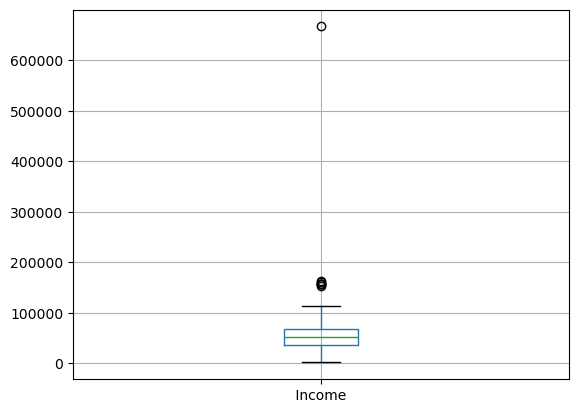

In [28]:
data[[' Income ']].boxplot()
plt.show()

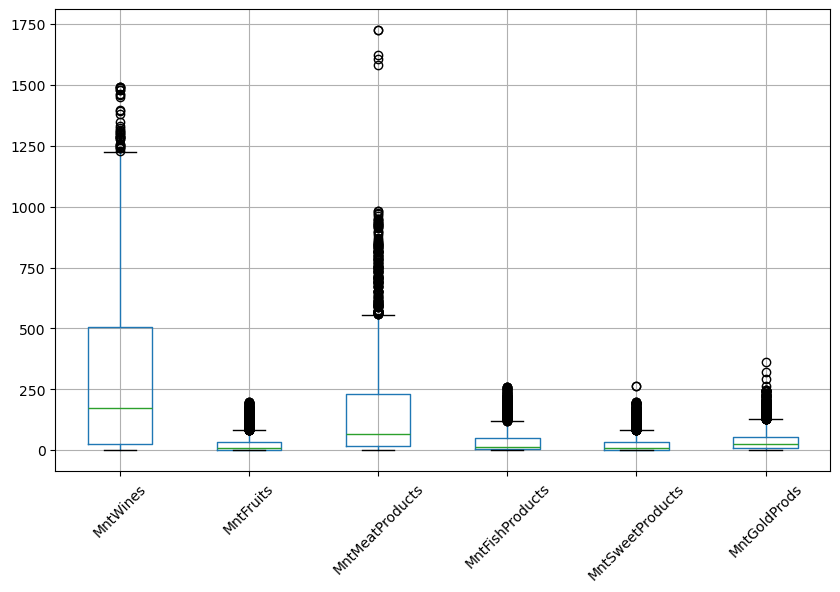

In [29]:
cols = ['MntWines','MntFruits','MntMeatProducts',
        'MntFishProducts','MntSweetProducts','MntGoldProds']

data[cols].boxplot(figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

箱线图显示 Income 及部分消费金额变量存在离群值，这主要来自高收入和高消费客户。这些数值属于正常差异，并非数据错误。

# 2. Feature Engineering

To enhance our analysis, we create new variables such as age, total spending, and total purchases.


## 2.1 Age Calculation
We compute customer age based on birth year.


In [33]:
# 计算年龄（当前年份）自动版
import datetime
current_year = datetime.datetime.now().year
data['Age'] = current_year - data['Year_Birth']
data[['Year_Birth','Age']].head()

,Year_Birth,Age
0,1970,56
1,1961,65
2,1958,68
3,1967,59
4,1989,37


## 2.2 Total Spending
We compute total spending across all product categories.


In [35]:
#总消费
spending_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
data['Total_Spending'] = data[spending_cols].sum(axis=1)
data[['Total_Spending']].head()

,Total_Spending
0,1190
1,577
2,251
3,11
4,91


## 2.3 Total Purchases
We calculate total purchases across all sales channels.


In [36]:
# 总购买次数
purchase_cols = ['NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
data['Total_Purchases'] = data[purchase_cols].sum(axis=1)
data[['Total_Purchases']].head()

,Total_Purchases
0,15
1,18
2,11
3,4
4,8


# 3. Exploratory Data Analysis

## 3.1 Income Distribution
We examine the distribution of customer income.


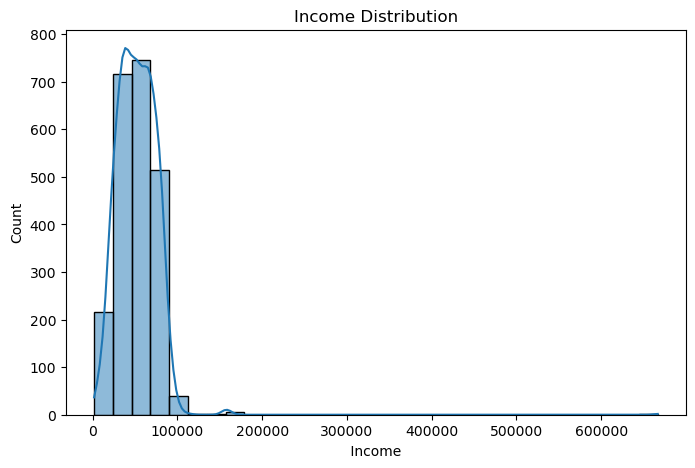

count      2240.000000
mean      52237.975446
std       25037.955891
min        1730.000000
25%       35538.750000
50%       51381.500000
75%       68289.750000
max      666666.000000
Name:  Income , dtype: float64

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
#用户收入情况直方图
# Income Histogram
plt.figure(figsize=(8,5))
sns.histplot(data[' Income '], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()
# Summary statistics
data[' Income '].describe()

## 3.2 Product Spending Patterns
We analyze which product categories generate the highest revenue.


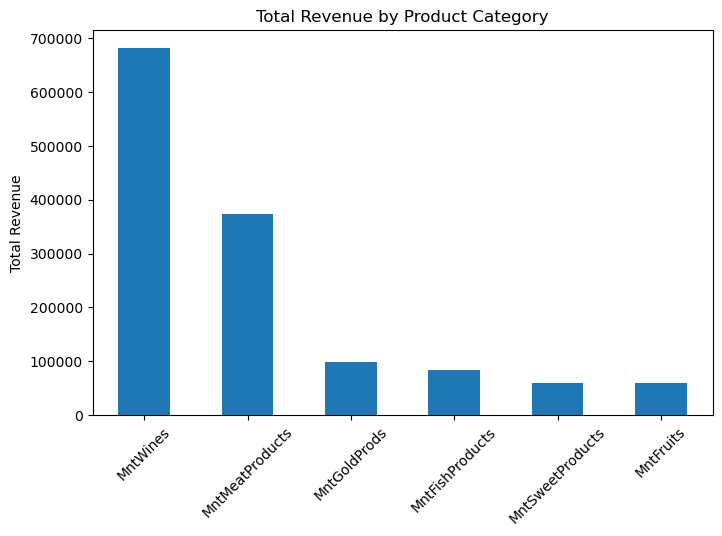

MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64

In [55]:
spending_cols = ['MntWines','MntFruits','MntMeatProducts',
                 'MntFishProducts','MntSweetProducts','MntGoldProds']
# Total revenue per category
total_revenue = data[spending_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
total_revenue.plot(kind='bar')

plt.title("Total Revenue by Product Category")
#总支出
#商品划分
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.show()
total_revenue

## 3.3 Purchase Channels采购渠道
We compare online, catalog, and in-store purchases.


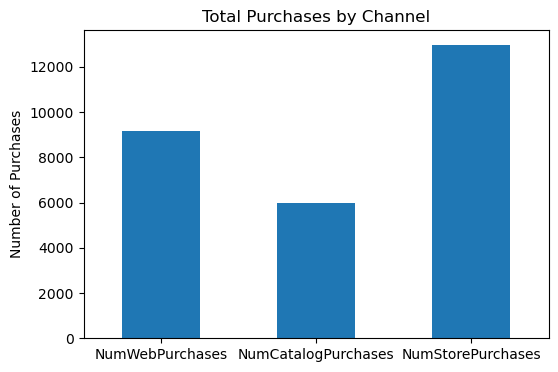

NumWebPurchases         9150
NumCatalogPurchases     5963
NumStorePurchases      12970
dtype: int64

In [56]:
purchase_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
channel_totals = data[purchase_cols].sum()
plt.figure(figsize=(6,4))
channel_totals.plot(kind='bar')
plt.title("Total Purchases by Channel")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=0)
plt.show()

channel_totals

In-store purchases dominate, followed by web purchases, while catalog purchases are the least preferred channel.
线下门店购买占比最高，其次是线上购买，目录渠道最少。

## 3.4 Customer Demographics
We explore age, education, and marital status distribution.


Age Distribution

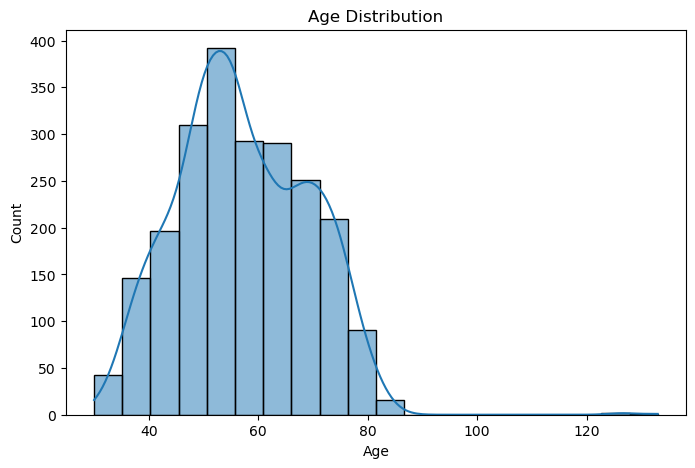

In [57]:
plt.figure(figsize=(8,5))
sns.histplot(data['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

Education Distribution

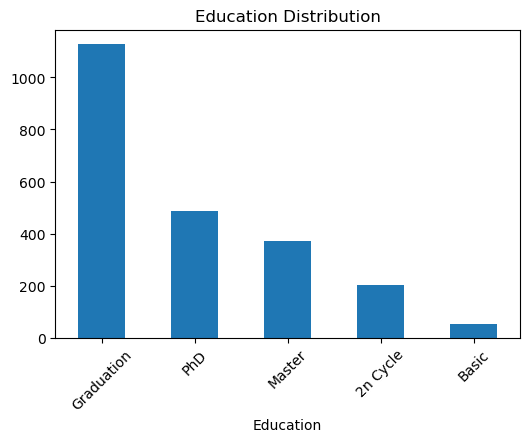

In [58]:
plt.figure(figsize=(6,4))
data['Education'].value_counts().plot(kind='bar')
plt.title("Education Distribution")
plt.xticks(rotation=45)
plt.show()

Marital Status Distribution

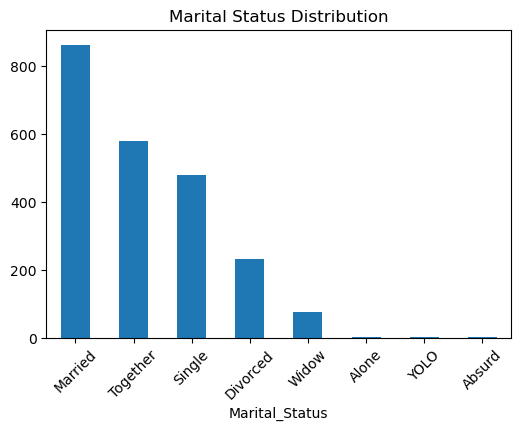

In [59]:
plt.figure(figsize=(6,4))
data['Marital_Status'].value_counts().plot(kind='bar')
plt.title("Marital Status Distribution")
plt.xticks(rotation=45)
plt.show()

# 4. Statistical Analysis

We conduct regression and hypothesis testing to answer the key business questions.


## 4.1 Factors Affecting Store Purchases回归

We run a regression model to identify significant predictors of in-store purchases.


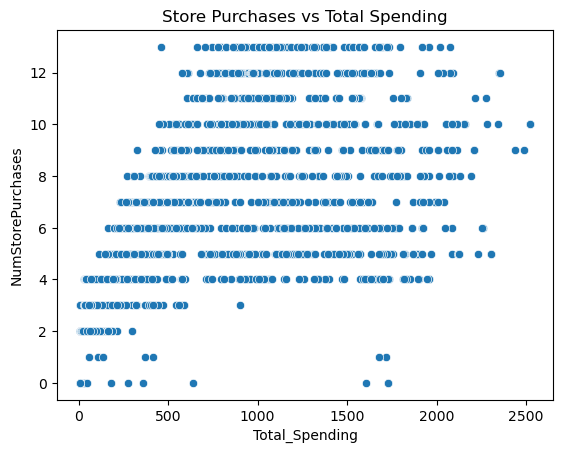

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=data['Total_Spending'], y=data['NumStorePurchases'])
plt.title("Store Purchases vs Total Spending")
plt.show()

## 4.2 US vs Rest of the World

We test whether customers from the US make significantly more purchases than customers from other countries.


In [73]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age',
       'Total_Spending', 'Total_Purchases', 'US_flag'],
      dtype='object')

In [74]:
data['US_flag'] = (data['Country'] == 'US').astype(int)

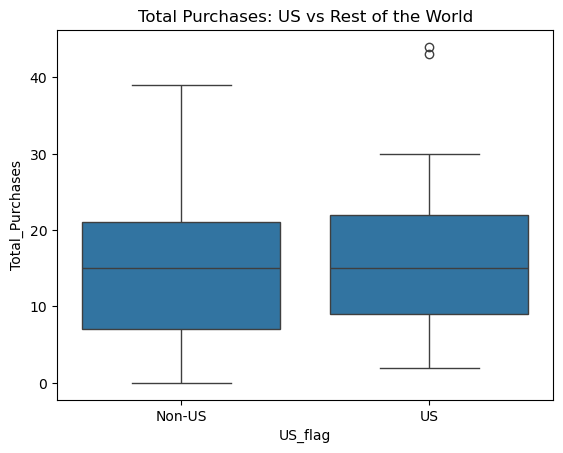

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='US_flag', y='Total_Purchases', data=data)
plt.xticks([0,1], ['Non-US','US'])
plt.title("Total Purchases: US vs Rest of the World")
plt.show()

In [ ]:
#看看 US 平均购买次数是否更高
data.groupby('US_flag')['Total_Purchases'].mean()

如果 p-value < 0.05：差异显著：US 客户确实购买更多
如果 p-value > 0.05：差异不显著

In [78]:
from scipy.stats import ttest_ind

us = data[data['US_flag']==1]['Total_Purchases']
non_us = data[data['US_flag']==0]['Total_Purchases']

ttest_ind(us, non_us)

TtestResult(statistic=np.float64(1.8049578917961837), pvalue=np.float64(0.07121562869350609), df=np.float64(2238.0))

虽然美国客户的平均购买次数略高于其他国家客户，但差异在统计上不显著（p = 0.071 > 0.05）。因此，我们无法得出美国客户购买次数显著更多的结论。

## 4.3 Gold Spending Hypothesis

We test whether customers who spend above-average amounts on gold products make more in-store purchases.


In [79]:
data['High_Gold'] = (data['MntGoldProds'] > data['MntGoldProds'].mean()).astype(int)

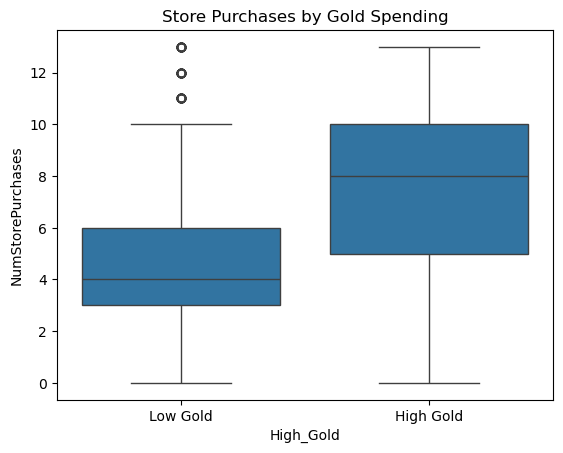

In [80]:
sns.boxplot(x=data['High_Gold'], y=data['NumStorePurchases'])
plt.xticks([0,1], ['Low Gold','High Gold'])
plt.title("Store Purchases by Gold Spending")
plt.show()

高黄金消费客户明显更常进行线下购买。

In [83]:
from scipy.stats import ttest_ind

high = data[data['High_Gold']==1]['NumStorePurchases']
low = data[data['High_Gold']==0]['NumStorePurchases']

ttest_ind(high, low)

TtestResult(statistic=np.float64(21.086131064280845), pvalue=np.float64(3.557265498792722e-90), df=np.float64(2238.0))

这表明黄金产品的高消费群体更倾向于进行线下购物

## 4.4 Married PhD & Fish Spending (Interaction Effect)

We investigate whether married customers with PhDs spend significantly more on fish products using an interaction term.


In [84]:
data['Married_flag'] = (data['Marital_Status'] == 'Married').astype(int)
data['PhD_flag'] = (data['Education'] == 'PhD').astype(int)

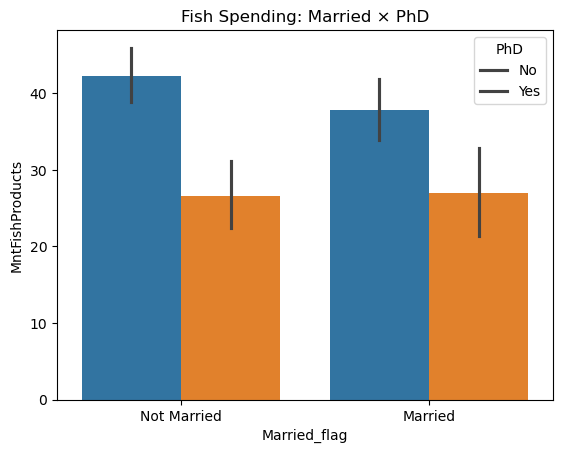

In [85]:
sns.barplot(x='Married_flag',
            y='MntFishProducts',
            hue='PhD_flag',
            data=data)

plt.xticks([0,1], ['Not Married','Married'])
plt.legend(title='PhD', labels=['No','Yes'])
plt.title("Fish Spending: Married × PhD")
plt.show()

教育水平影响鱼消费，
婚姻状态影响不明显，
两者没有明显交互作用。

## 4.5 Campaign Success by Region

We examine whether geographical region significantly affects campaign response rates.


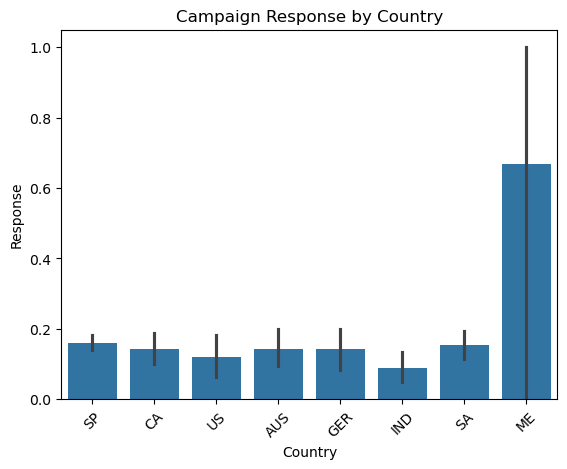

In [88]:
sns.barplot(x='Country', y='Response', data=data)
plt.xticks(rotation=45)
plt.title("Campaign Response by Country")
plt.show()

除了 ME 之外，各国家回应率差不多。国家影响不明显。

# 5. Data Visualization


## 5.1 Campaign Acceptance Rates
Which marketing campaign was the most successful?
We compare acceptance rates across campaigns.

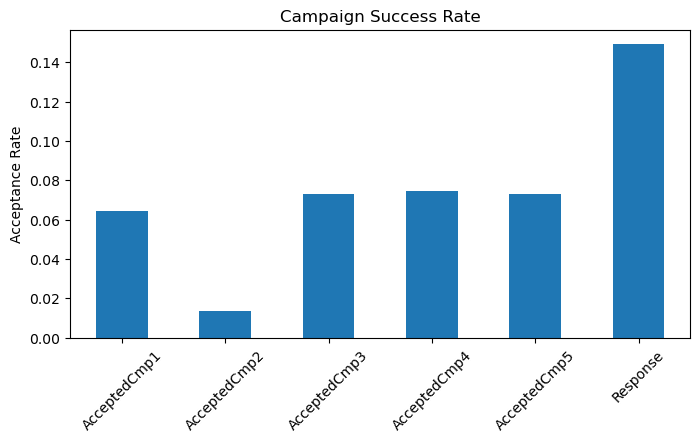

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                 'AcceptedCmp4','AcceptedCmp5','Response']

campaign_success = data[campaign_cols].mean()

plt.figure(figsize=(8,4))
campaign_success.plot(kind='bar')
plt.title("Campaign Success Rate")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation=45)
plt.show()

最成功的是：Response（最新活动）

## 5.2 customer portrait

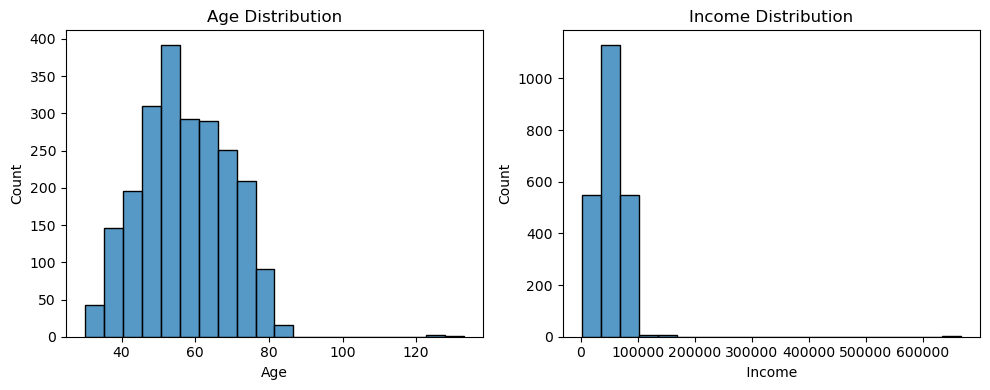

In [94]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data['Age'], bins=20)
plt.title("Age Distribution")

plt.subplot(1,2,2)
sns.histplot(data[' Income '], bins=20)
plt.title("Income Distribution")

plt.tight_layout()
plt.show()

公司客户主要是中年、中等收入人群。

## 5.3 Best-selling

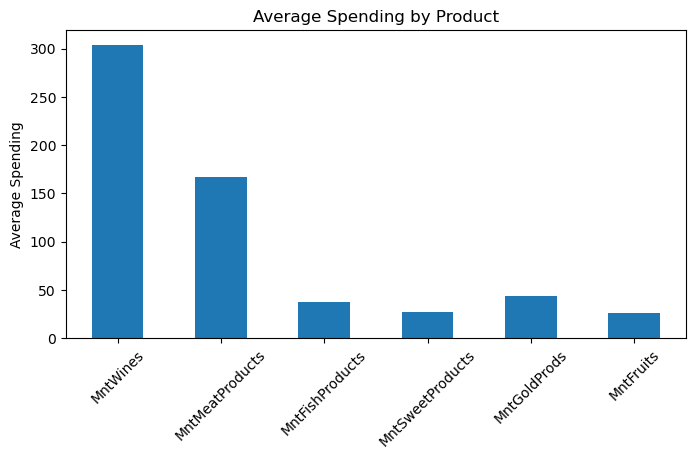

In [95]:
product_cols = ['MntWines','MntMeatProducts','MntFishProducts',
                'MntSweetProducts','MntGoldProds','MntFruits']

product_avg = data[product_cols].mean()

plt.figure(figsize=(8,4))
product_avg.plot(kind='bar')
plt.title("Average Spending by Product")
plt.ylabel("Average Spending")
plt.xticks(rotation=45)
plt.show()

MntWines是绝对主力产品

## 5.4 Poor channel performance

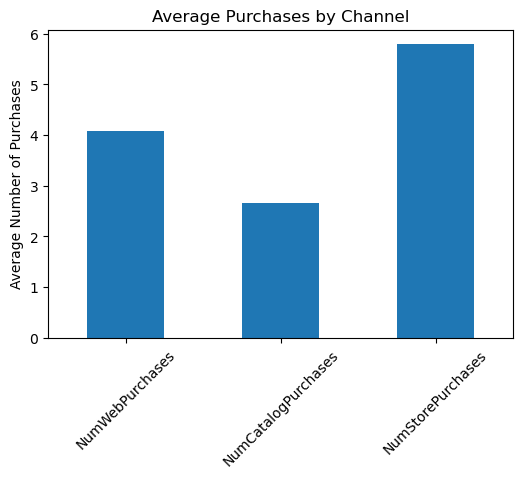

In [96]:
channel_cols = ['NumWebPurchases',
                'NumCatalogPurchases',
                'NumStorePurchases']

channel_avg = data[channel_cols].mean()

plt.figure(figsize=(6,4))
channel_avg.plot(kind='bar')
plt.title("Average Purchases by Channel")
plt.ylabel("Average Number of Purchases")
plt.xticks(rotation=45)
plt.show()

表现最差的是：Catalog 渠道